In [40]:
import os
import glob
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
import torchvision.transforms as T
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ================= Dataset Class =================
class MVTecAnomalyDataset(Dataset):
    def __init__(self, root_dir, transform=None, mask_transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.mask_transform = mask_transform
        self.samples = []
        self.labels = []
        self.mask_paths = []
        self.defect_types = []

        print(f"🔍 جاري فحص المجلد: {root_dir}")

        if os.path.exists(os.path.join(root_dir, 'train')):
            categories = ['.']
        else:
            categories = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

        for category in categories:
            category_path = root_dir if category == '.' else os.path.join(root_dir, category)
            train_path = os.path.join(category_path, 'train')
            test_path = os.path.join(category_path, 'test')
            ground_truth_path = os.path.join(category_path, 'ground_truth')

            if os.path.exists(train_path):
                good_path = os.path.join(train_path, 'good')
                if os.path.exists(good_path):
                    train_images = []
                    for ext in ['*.png', '*.jpg', '*.jpeg']:
                        train_images.extend(glob.glob(os.path.join(good_path, ext)))
                    for img_path in train_images:
                        self.samples.append(img_path)
                        self.labels.append(0)
                        self.mask_paths.append(None)

            if os.path.exists(test_path):
                defect_folders = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]
                for defect_type in defect_folders:
                    defect_path = os.path.join(test_path, defect_type)
                    test_images = []
                    for ext in ['*.png', '*.jpg', '*.jpeg']:
                        test_images.extend(glob.glob(os.path.join(defect_path, ext)))
                    for img_path in test_images:
                        self.samples.append(img_path)
                        if defect_type == 'good':
                            self.labels.append(0)
                            self.mask_paths.append(None)
                        else:
                            self.labels.append(1)
                            self.mask_paths.append(self._find_mask(img_path, ground_truth_path, defect_type))

        print(f"📊 إحصائيات: Normal: {self.labels.count(0)}, Anomaly: {self.labels.count(1)}")

    def _find_mask(self, img_path, ground_truth_path, defect_type):
        if not os.path.exists(ground_truth_path): return None
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        for ext in ['_mask.png', '.png']:
            p = os.path.join(ground_truth_path, defect_type, img_name + ext)
            if os.path.exists(p): return p
        return None

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        image = Image.open(self.samples[idx]).convert('RGB')
        label = self.labels[idx]
        mask = torch.zeros((1, 256, 256))
        if self.mask_paths[idx]:
            mask = T.ToTensor()(Image.open(self.mask_paths[idx]).convert('L').resize((256, 256)))
        if self.transform: image = self.transform(image)
        return image, label, mask, self.samples[idx]

# ================= Helpers =================
def load_mvtec(root_dir, batch_size=32):
    t = T.Compose([T.Resize((256, 256)), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    ds = MVTecAnomalyDataset(root_dir, transform=t)
    idx = list(range(len(ds)))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, stratify=ds.labels, random_state=42)

    def collate(b):
        return torch.stack([x[0] for x in b]), torch.tensor([x[1] for x in b]), torch.stack([x[2] for x in b]), [x[3] for x in b]

    tr_l = DataLoader(torch.utils.data.Subset(ds, tr_idx), batch_size=batch_size, shuffle=True, collate_fn=collate)
    te_l = DataLoader(torch.utils.data.Subset(ds, te_idx), batch_size=batch_size, collate_fn=collate)
    return tr_l, te_l



🔍 جاري فحص المجلد: /content/drive/MyDrive/datasits/mvtec_anomaly_detection
📊 إحصائيات: Normal: 4096, Anomaly: 1258


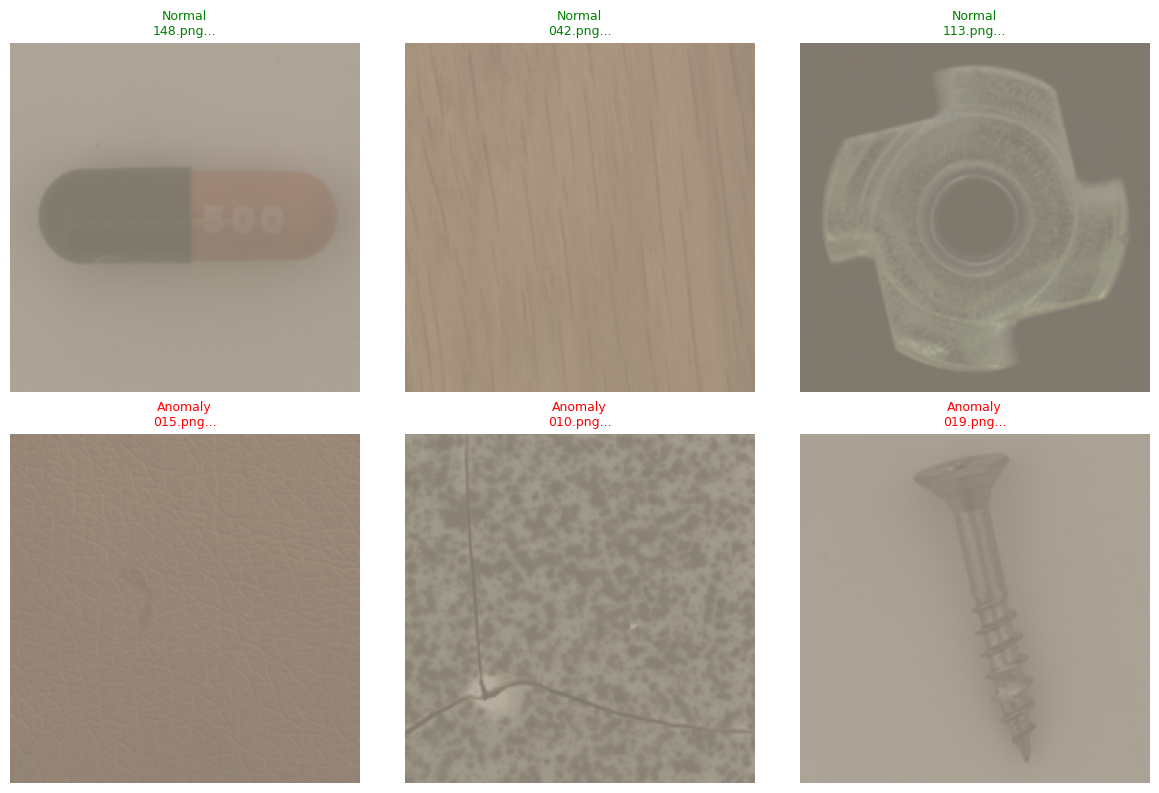

In [48]:
def visualize_specific_samples_compact(dataset):
    # البحث عن عينات سليمة وعينات بها عيوب
    normal_indices = [i for i, label in enumerate(dataset.labels) if label == 0]
    anomaly_indices = [i for i, label in enumerate(dataset.labels) if label == 1]

    # اختيار 3 من كل نوع
    selected_normal = np.random.choice(normal_indices, 3, replace=False)
    selected_anomaly = np.random.choice(anomaly_indices, 3, replace=False)
    all_indices = np.concatenate([selected_normal, selected_anomaly])

    # حجم أصغر وشبكة 2 صفوف × 3 أعمدة (فقط الصور لتوفير المساحة)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    to_tensor = T.Compose([T.Resize((256, 256)), T.ToTensor()])

    for i, idx in enumerate(all_indices):
        image, label, mask, path = dataset[idx]
        row, col = i // 3, i % 3

        if not isinstance(image, torch.Tensor): image = to_tensor(image)

        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)

        axes[row, col].imshow(img_display)
        color = 'green' if label == 0 else 'red'
        status = "Normal" if label == 0 else "Anomaly"
        axes[row, col].set_title(f"{status}\n{os.path.basename(path)[:15]}...", color=color, fontsize=9)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# تنفيذ العرض المضغوط
full_ds = MVTecAnomalyDataset(DATA_PATH)
visualize_specific_samples_compact(full_ds)

In [45]:
class FastFlowAnomalyDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = wide_resnet50_2(weights=Wide_ResNet50_2_Weights.IMAGENET1K_V2)
        # تجميد الطبقات الأولى وتدريب الطبقات الأخيرة فقط
        for p in list(self.backbone.parameters())[:-10]: p.requires_grad = False
        self.classifier = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(2048, 1))

    def forward(self, x):
        # استخراج الخصائص من الطبقة الرابعة
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        return self.classifier(x)

# ================= Train Loop =================
def train(model, tr_l, te_l, epochs=3):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"🚀 بدء التدريب على: {device}")
    model.to(device)
    opt = optim.AdamW(model.parameters(), lr=1e-4)
    crit = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        pbar = tqdm(tr_l, desc=f"Epoch {epoch+1}/{epochs}")
        for imgs, lbls, _, _ in pbar:
            imgs, lbls = imgs.to(device), lbls.float().to(device).unsqueeze(1)
            opt.zero_grad()
            outputs = model(imgs)
            loss = crit(outputs, lbls)
            loss.backward()
            opt.step()
            train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        # التقييم (Validation)
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for imgs, lbls, _, _ in te_l:
                imgs = imgs.to(device)
                outputs = model(imgs)
                preds = torch.sigmoid(outputs).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(lbls.numpy())

        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        binary_preds = (all_preds > 0.5).astype(int)

        acc = (binary_preds.flatten() == all_labels).mean()
        auc = roc_auc_score(all_labels, all_preds)
        f1 = f1_score(all_labels, binary_preds)

        print(f"✅ Epoch {epoch+1} | Accuracy: {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}")

    torch.save(model.state_dict(), '/content/best_model.pth')
    print("🎉 تم حفظ الموديل بنجاح!")

# تشغيل التدريب
DATA_PATH = "/content/drive/MyDrive/datasits/mvtec_anomaly_detection"
tr_l, te_l = load_mvtec(DATA_PATH)
model = FastFlowAnomalyDetector()
train(model, tr_l, te_l)

🔍 جاري فحص المجلد: /content/drive/MyDrive/datasits/mvtec_anomaly_detection
📊 إحصائيات: Normal: 4096, Anomaly: 1258
🚀 بدء التدريب على: cuda


Epoch 1/3:   0%|          | 0/134 [00:00<?, ?it/s]

✅ Epoch 1 | Accuracy: 0.8431 | AUC: 0.9067 | F1: 0.5059


Epoch 2/3:   0%|          | 0/134 [00:00<?, ?it/s]

✅ Epoch 2 | Accuracy: 0.8711 | AUC: 0.9079 | F1: 0.6368


Epoch 3/3:   0%|          | 0/134 [00:00<?, ?it/s]

✅ Epoch 3 | Accuracy: 0.8833 | AUC: 0.9267 | F1: 0.6803
🎉 تم حفظ الموديل بنجاح!


In [47]:
# 1. إنشاء نسخة جديدة من الموديل وتحميل الأوزان
model = FastFlowAnomalyDetector()
model_path = '/content/best_model.pth'

if os.path.exists(model_path):
    print(f"🔄 جاري تحميل الموديل المحفوظ من: {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print("⚠️ لم يتم العثور على أوزان سابقة، سيبدأ التدريب من الصفر.")

# 2. تحميل البيانات
DATA_PATH = "/content/drive/MyDrive/datasits/mvtec_anomaly_detection"
tr_l, te_l = load_mvtec(DATA_PATH)

# 3. تدريب لـ 3 دورات إضافية
train(model, tr_l, te_l, epochs=3)

# 4. حفظ وتنزيل الموديل النهائي
import shutil
from google.colab import files

final_model_save = '/content/final_mvtec_model.pth'
torch.save(model.state_dict(), final_model_save)
zip_name = '/content/mvtec_anomaly_model_final'
shutil.make_archive(zip_name, 'zip', os.path.dirname(final_model_save), os.path.basename(final_model_save))

print("✅ تم حفظ الموديل النهائي وضغطه. جاري بدء التحميل...")
files.download(f"{zip_name}.zip")

🔄 جاري تحميل الموديل المحفوظ من: /content/best_model.pth
🔍 جاري فحص المجلد: /content/drive/MyDrive/datasits/mvtec_anomaly_detection
📊 إحصائيات: Normal: 4096, Anomaly: 1258
🚀 بدء التدريب على: cuda


Epoch 1/3:   0%|          | 0/134 [00:00<?, ?it/s]

✅ Epoch 1 | Accuracy: 0.9206 | AUC: 0.9554 | F1: 0.8140


Epoch 2/3:   0%|          | 0/134 [00:00<?, ?it/s]

✅ Epoch 2 | Accuracy: 0.9094 | AUC: 0.9537 | F1: 0.7749


Epoch 3/3:   0%|          | 0/134 [00:00<?, ?it/s]

✅ Epoch 3 | Accuracy: 0.9169 | AUC: 0.9462 | F1: 0.8018
🎉 تم حفظ الموديل بنجاح!
✅ تم حفظ الموديل النهائي وضغطه. جاري بدء التحميل...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🔍 جاري فحص المجلد: /content/drive/MyDrive/datasits/mvtec_anomaly_detection
📊 إحصائيات: Normal: 4096, Anomaly: 1258


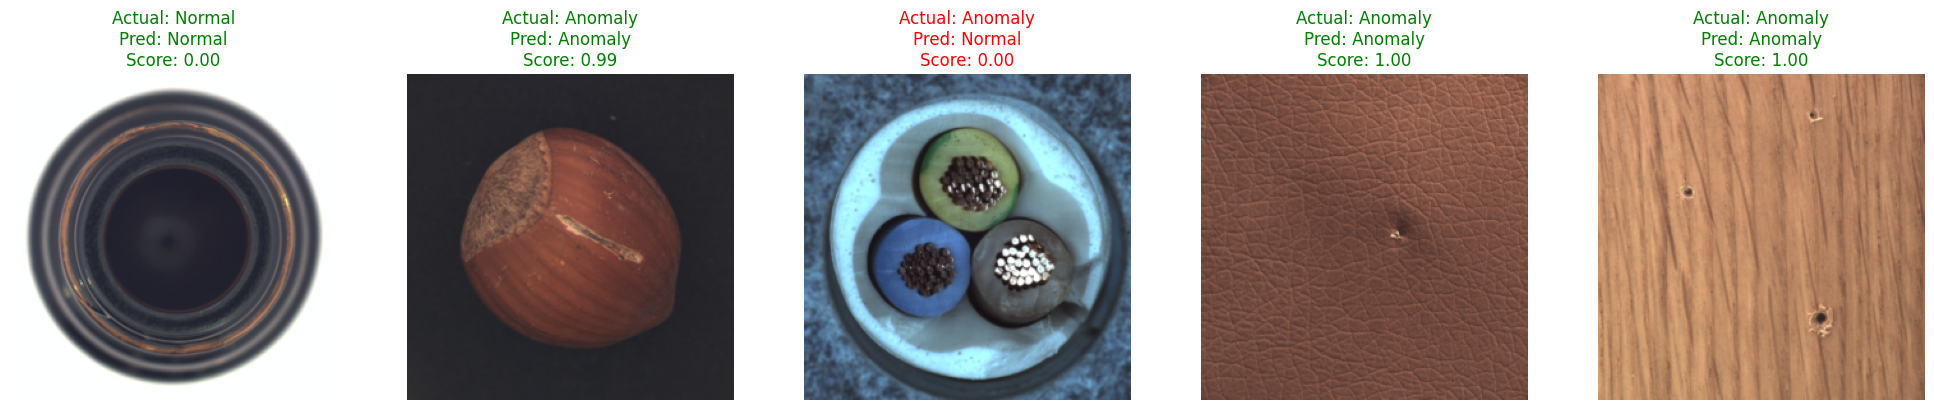

In [49]:
def test_and_visualize_custom(model, dataset, n_normal=1, n_anomaly=4):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()

    # البحث عن عينات
    normal_indices = [i for i, label in enumerate(dataset.labels) if label == 0]
    anomaly_indices = [i for i, label in enumerate(dataset.labels) if label == 1]

    selected_indices = []
    selected_indices.extend(np.random.choice(normal_indices, n_normal, replace=False))
    selected_indices.extend(np.random.choice(anomaly_indices, n_anomaly, replace=False))

    plt.figure(figsize=(20, 4))

    for i, idx in enumerate(selected_indices):
        image, label, mask, path = dataset[idx]

        # التحويل للمعالجة
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            score = torch.sigmoid(output).item()
            pred_label = 1 if score > 0.5 else 0

        # التحويل للعرض
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img_display)
        actual_str = "Normal" if label == 0 else "Anomaly"
        pred_str = "Normal" if pred_label == 0 else "Anomaly"
        color = 'green' if label == pred_label else 'red'

        plt.title(f"Actual: {actual_str}\nPred: {pred_str}\nScore: {score:.2f}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# تحميل الداتا والموديل النهائي للتجربة
full_dataset = MVTecAnomalyDataset(DATA_PATH, transform=T.Compose([T.Resize((256, 256)), T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]))
test_and_visualize_custom(model, full_dataset)